JOB SCAMS SURVEY ANALYSIS: SOCIAL PROOF & INFORMATIONAL CASCADES

Dataset loaded: 96 responses
Total columns: 62

DATA PREPARATION

✓ Numeric scales extracted successfully

✓ Binary payment variable created: 16.0 paid out of 37 valid responses
  Missing payment data: 59
✓ Payment range: ₹0 - ₹75000
  Missing payment amounts: 81
✓ Age groups: 8 categories
  Missing age data: 6
✓ Professional appearance: 3.0 cases (out of 37 valid)
  Missing: 59

DESCRIPTIVE STATISTICS

--- Key Variables Summary ---
       social_proof_scale  sunk_cost_scale  confidence_scale  \
count               37.00            37.00             91.00   
mean                 2.41             2.22              3.33   
std                  1.24             1.08              1.13   
min                  1.00             1.00              1.00   
25%                  1.00             1.00              3.00   
50%                  2.00             2.00              3.00   
75%                  3.00             3.00       

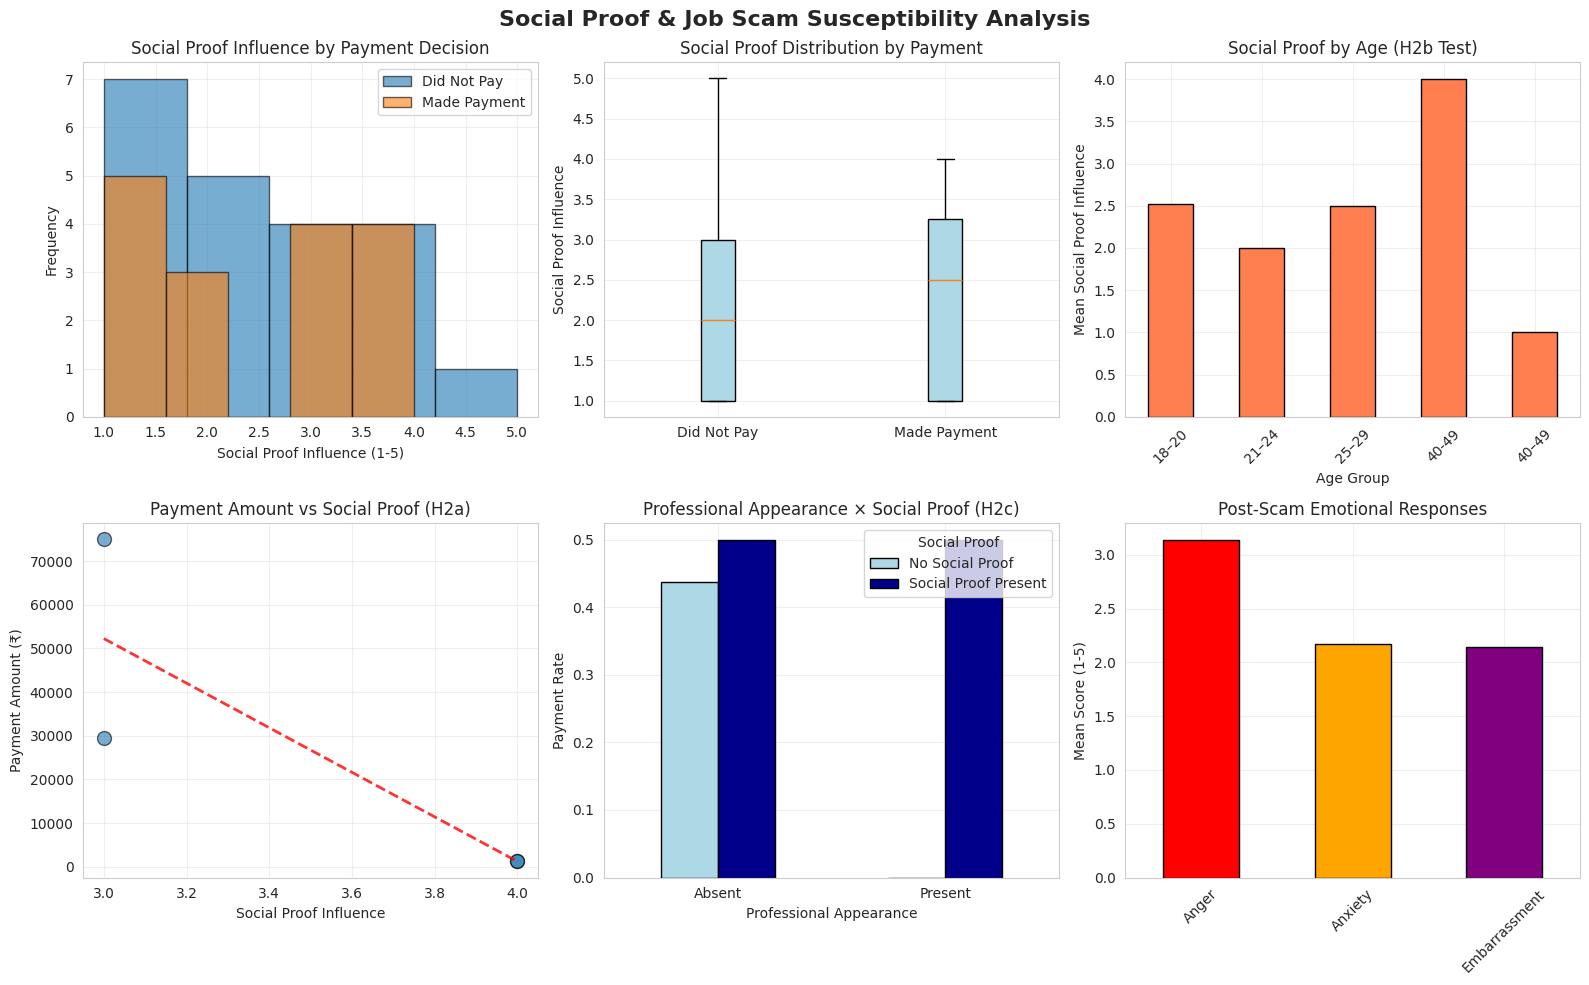

✓ Visualizations generated

HYPOTHESIS TESTING

--- H2a: Social Proof Effect on Payment ---
Mann-Whitney U Test:
  U-statistic: 174.00
  p-value: 0.4308
  Median (Paid): 2.50
  Median (Not Paid): 2.00
  Effect size (r): -0.036
  ✗ NOT SIGNIFICANT: No clear social proof effect (H2a not supported)

--- H2b: Age Moderation Effect ---
Younger (≤24):
  Correlation: 0.040 (p=0.8256)
  N: 33

Comparison:
  Younger correlation: 0.040
  Older correlation: -0.500
  Difference: 0.540
  → H2b not clearly supported

--- H2c: Professional Appearance × Social Proof ---

Contingency Table (Professional × Social Proof):
social_proof_element     0.0  1.0
professional_appearance          
0.0                       32    2
1.0                        1    2
Valid cases: 37

Payment Rates by Combination:
                                               mean  count
professional_appearance social_proof_element              
0.0                     0.0                   0.438     32
                        1.0  

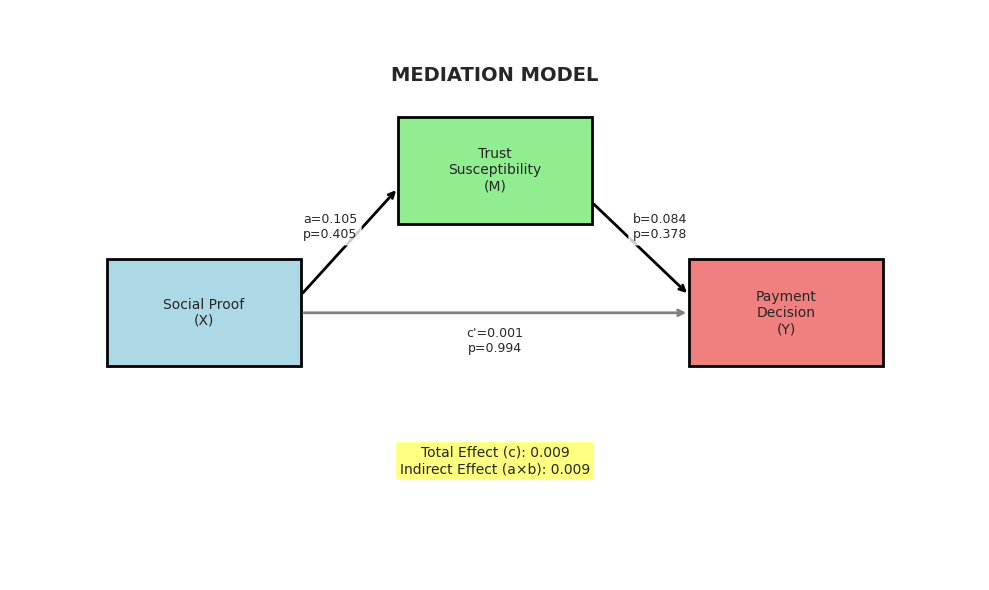

✓ Mediation diagram generated

ADDITIONAL INSIGHTS

--- Sunk Cost Effect ---
Sunk cost influence (Paid): 3.00
Sunk cost influence (Not Paid): 2.00
Mann-Whitney U: 210.50, p=0.0897

--- Psychological Factors Correlation ---


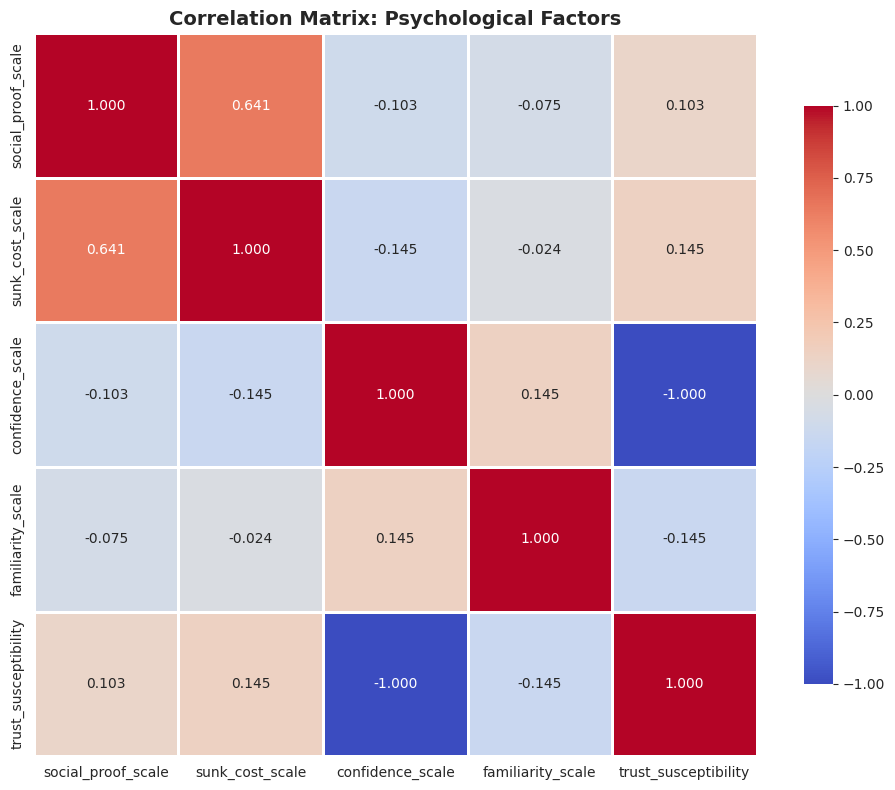

✓ Correlation heatmap generated

Key correlations:
  social_proof_scale ↔ sunk_cost_scale: 0.641
  confidence_scale ↔ trust_susceptibility: -1.000

--- Payment Decision Factors ---


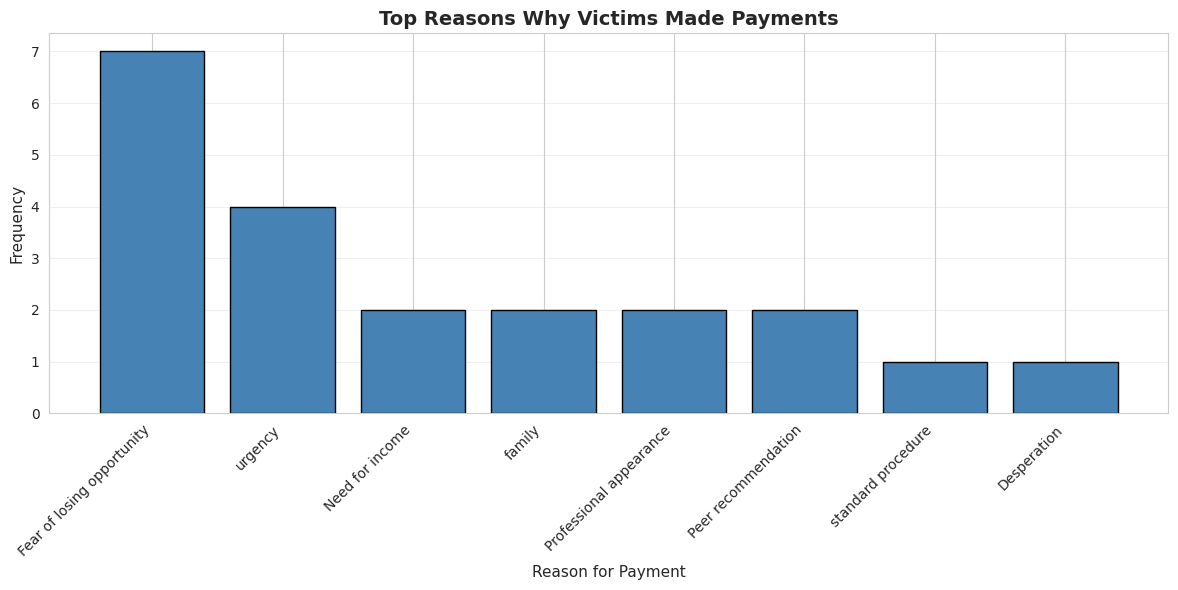

Top 3 reasons for payment:
  1. Fear of losing opportunity: 7 mentions
  2. urgency: 4 mentions
  3. Need for income: 2 mentions

--- Post-Scam Emotional Impact ---

Emotional responses (N=35):
  Anger: Mean=3.14, SD=1.46
  Anxiety: Mean=2.17, SD=1.34
  Embarrassment: Mean=2.14, SD=1.50

PREDICTIVE MODELING: Logistic Regression

Model data: N=36, Payment rate=44.44%

--- Model Performance ---
Accuracy: 0.667
AUC-ROC: 0.767

Confusion Matrix:
[[16  4]
 [ 8  8]]

Classification Report:
              precision    recall  f1-score   support

 Did Not Pay       0.67      0.80      0.73        20
        Paid       0.67      0.50      0.57        16

    accuracy                           0.67        36
   macro avg       0.67      0.65      0.65        36
weighted avg       0.67      0.67      0.66        36


--- Feature Importance (Coefficients) ---
                Feature  Coefficient  Abs_Coefficient
            age_numeric     0.733618         0.733618
       confidence_scale    -0.665

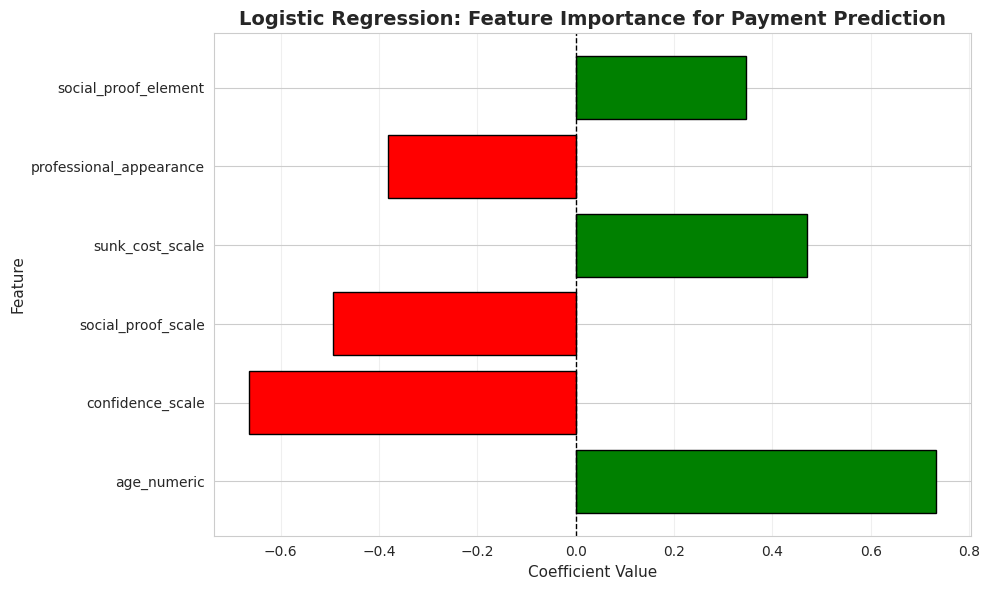

✓ Feature importance plot generated

--- Odds Ratios (for 1 SD increase) ---
                Feature  Odds Ratio Interpretation
            age_numeric    2.082602 +108.3% change
        sunk_cost_scale    1.602041  +60.2% change
   social_proof_element    1.412961  +41.3% change
professional_appearance    0.682531  -31.7% change
     social_proof_scale    0.610370  -39.0% change
       confidence_scale    0.514130  -48.6% change

SUMMARY & THEORETICAL IMPLICATIONS

THEORETICAL FRAMEWORK: Social Proof & Informational Cascades (Cialdini; Bikhchandani et al.)

KEY FINDINGS:

1. SOCIAL PROOF EFFECT (H2a):
   - Tested whether higher social proof influence predicts payment decisions
   - Method: Mann-Whitney U test (non-parametric for small samples)
   - Look for: Significant difference in social proof ratings between payers vs non-payers
   
2. AGE MODERATION (H2b):
   - Tested whether younger individuals are more susceptible to social proof
   - Method: Spearman correlations by age group,

In [ ]:
"""
Job Scams Survey Analysis: Social Proof & Informational Cascades
Focuses on H2a, H2b, H2c with mediation analysis
Handles small datasets and missing data appropriately
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, kruskal
import statsmodels.api as sm
from statsmodels.stats.mediation import Mediation
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# ==========================
# 1. LOAD AND PREPARE DATA
# ==========================

print("="*80)
print("JOB SCAMS SURVEY ANALYSIS: SOCIAL PROOF & INFORMATIONAL CASCADES")
print("="*80)

# Load data
df = pd.read_excel('responses.xlsx')

print(f"\nDataset loaded: {len(df)} responses")
print(f"Total columns: {len(df.columns)}")

# ==========================
# 2. DATA CLEANING & FEATURE ENGINEERING
# ==========================

print("\n" + "="*80)
print("DATA PREPARATION")
print("="*80)

# Key column mapping (adjust based on exact column names)
col_map = {
    'social_proof': 'How much did social proof (likes/testimonials) influence your decision to continue?',
    'sunk_cost': 'How much did the time and effort you had already invested influence your decision to continue?',
    'age': 'Age band',
    'engagement': 'Did you engage with it at all?',
    'payment_amount': 'Total amount paid (approx.)',
    'elements_noticed': 'Which elements did you notice? (select all that apply)',
    'encounter': 'In the past 12 months, have you personally encountered any suspicious job/internship offers or tasks?',
    'scam_type': 'Which BEST describes this encounter?',
    'confidence': 'How confident are you that you can recognize a job scam when you see one?',
    'familiarity': 'Before today, how familiar were you with the idea of job scams?',
    'payment_reasons': 'What affected you to pay at the time? (only if applied, select all top reasons)',
    'tactics_used': 'Which tactics were used? (select all that apply)',
    'anger': 'After this experience, how much did you feel: Anger',
    'anxiety': 'After this experience, how much did you feel: Anxiety',
    'embarrassment': 'After this experience, how much did you feel: Embarrassment'
}

# Create working dataframe with renamed columns
df_work = df.copy()

# Extract key variables
try:
    df_work['social_proof_scale'] = pd.to_numeric(df[col_map['social_proof']], errors='coerce')
    df_work['sunk_cost_scale'] = pd.to_numeric(df[col_map['sunk_cost']], errors='coerce')
    df_work['confidence_scale'] = pd.to_numeric(df[col_map['confidence']], errors='coerce')
    df_work['familiarity_scale'] = pd.to_numeric(df[col_map['familiarity']], errors='coerce')

    # Emotional responses
    df_work['anger_scale'] = pd.to_numeric(df[col_map['anger']], errors='coerce')
    df_work['anxiety_scale'] = pd.to_numeric(df[col_map['anxiety']], errors='coerce')
    df_work['embarrassment_scale'] = pd.to_numeric(df[col_map['embarrassment']], errors='coerce')

    print("\n✓ Numeric scales extracted successfully")
except Exception as e:
    print(f"\n✗ Error extracting scales: {e}")

# Create binary payment variable - NO REPLACEMENT OF MISSING VALUES
df_work['made_payment'] = np.nan  # Start with NaN
payment_indicators = [
    'Yes, including payment',
    '₹500–₹1,999', '₹2,000–₹4,999', '₹5,000–₹9,999',
    '₹10,000–₹49,999', '₹50,000+', 'Less than ₹500'
]

# Only set to 1 where we have evidence of payment
if col_map['engagement'] in df.columns:
    df_work.loc[df[col_map['engagement']].str.contains('payment', case=False, na=False), 'made_payment'] = 1

if col_map['payment_amount'] in df.columns:
    for indicator in payment_indicators:
        df_work.loc[df[col_map['payment_amount']].str.contains(indicator, case=False, na=False), 'made_payment'] = 1

# Set to 0 only where we have explicit evidence of NO payment
if col_map['engagement'] in df.columns:
    df_work.loc[df[col_map['engagement']].str.contains('No|briefly', case=False, na=False) & df_work['made_payment'].isna(), 'made_payment'] = 0

if col_map['payment_amount'] in df.columns:
    df_work.loc[df[col_map['payment_amount']].str.contains('did not pay|Not applicable', case=False, na=False) & df_work['made_payment'].isna(), 'made_payment'] = 0

# Numeric payment amount - KEEP AS NaN WHERE MISSING
df_work['payment_numeric'] = np.nan
payment_map = {
    'Less than ₹500': 250,
    '₹500–₹1,999': 1250,
    '₹2,000–₹4,999': 3500,
    '₹5,000–₹9,999': 7500,
    '₹10,000–₹49,999': 29500,
    '₹50,000+': 75000,
    'I did not pay': 0
}

if col_map['payment_amount'] in df.columns:
    for key, value in payment_map.items():
        df_work.loc[df[col_map['payment_amount']].str.contains(key, case=False, na=False), 'payment_numeric'] = value

# Age groups - KEEP AS NaN WHERE MISSING (no default values)
age_map = {
    'Below 18': 17,
    '18–20': 19,
    '21–24': 22.5,
    '25–29': 27,
    '30–39': 34.5,
    '40-49': 44.5,
    '50+': 55
}

df_work['age_numeric'] = df[col_map['age']].map(age_map)  # This naturally keeps NaN for missing
df_work['age_group'] = df[col_map['age']]  # Keep original, no filling

# Professional appearance indicator - KEEP AS NaN WHERE MISSING
df_work['professional_appearance'] = np.nan
if col_map['elements_noticed'] in df.columns:
    prof_keywords = ['professional', 'branding', 'website', 'verified', 'official', 'Professional appearance']
    # First set all non-missing to 0
    df_work.loc[df[col_map['elements_noticed']].notna(), 'professional_appearance'] = 0
    # Then set to 1 only where keywords found
    for keyword in prof_keywords:
        df_work.loc[df[col_map['elements_noticed']].str.contains(keyword, case=False, na=False), 'professional_appearance'] = 1

# Social proof indicator from elements - KEEP AS NaN WHERE MISSING
df_work['social_proof_element'] = np.nan
if col_map['elements_noticed'] in df.columns:
    social_keywords = ['testimonial', 'social proof', 'likes', 'views', 'reviews']
    # First set all non-missing to 0
    df_work.loc[df[col_map['elements_noticed']].notna(), 'social_proof_element'] = 0
    # Then set to 1 only where keywords found
    for keyword in social_keywords:
        df_work.loc[df[col_map['elements_noticed']].str.contains(keyword, case=False, na=False), 'social_proof_element'] = 1

# Trust proxy - ONLY calculate where confidence is not missing
df_work['trust_susceptibility'] = np.nan
df_work.loc[df_work['confidence_scale'].notna(), 'trust_susceptibility'] = 6 - df_work.loc[df_work['confidence_scale'].notna(), 'confidence_scale']

print(f"\n✓ Binary payment variable created: {df_work['made_payment'].sum()} paid out of {df_work['made_payment'].notna().sum()} valid responses")
print(f"  Missing payment data: {df_work['made_payment'].isna().sum()}")
print(f"✓ Payment range: ₹{df_work['payment_numeric'].min():.0f} - ₹{df_work['payment_numeric'].max():.0f}")
print(f"  Missing payment amounts: {df_work['payment_numeric'].isna().sum()}")
print(f"✓ Age groups: {df_work['age_group'].nunique()} categories")
print(f"  Missing age data: {df_work['age_numeric'].isna().sum()}")
print(f"✓ Professional appearance: {df_work['professional_appearance'].sum()} cases (out of {df_work['professional_appearance'].notna().sum()} valid)")
print(f"  Missing: {df_work['professional_appearance'].isna().sum()}")

# ==========================
# 3. DESCRIPTIVE STATISTICS
# ==========================

print("\n" + "="*80)
print("DESCRIPTIVE STATISTICS")
print("="*80)

# Overall statistics
print("\n--- Key Variables Summary ---")
key_vars = ['social_proof_scale', 'sunk_cost_scale', 'confidence_scale',
            'familiarity_scale', 'payment_numeric', 'age_numeric']

desc_stats = df_work[key_vars].describe()
print(desc_stats.round(2))

# Missing data analysis
print("\n--- Missing Data Analysis ---")
missing_pct = (df_work[key_vars].isna().sum() / len(df_work) * 100).round(1)
print(missing_pct[missing_pct > 0])

# Payment breakdown - work only with non-missing data
print("\n--- Payment Behavior ---")
valid_payment = df_work['made_payment'].notna().sum()
paid_count = df_work['made_payment'].sum()
not_paid_count = (df_work['made_payment']==0).sum()
missing_count = df_work['made_payment'].isna().sum()

print(f"Valid responses: {valid_payment}")
print(f"Paid: {paid_count} ({paid_count/valid_payment*100:.1f}% of valid)")
print(f"Did not pay: {not_paid_count} ({not_paid_count/valid_payment*100:.1f}% of valid)")
print(f"Missing data: {missing_count}")

if df_work['payment_numeric'].sum() > 0:
    paid_subset = df_work[df_work['payment_numeric'] > 0]
    print(f"\nAmong those who paid:")
    print(f"  Mean: ₹{paid_subset['payment_numeric'].mean():.0f}")
    print(f"  Median: ₹{paid_subset['payment_numeric'].median():.0f}")
    print(f"  Total: ₹{paid_subset['payment_numeric'].sum():.0f}")

# ==========================
# 4. VISUALIZATION: SOCIAL PROOF DISTRIBUTION
# ==========================

print("\n" + "="*80)
print("VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Social Proof & Job Scam Susceptibility Analysis', fontsize=16, fontweight='bold')

# Plot 1: Social proof distribution by payment
ax1 = axes[0, 0]
payment_labels = ['Did Not Pay', 'Made Payment']
for i, paid in enumerate([0, 1]):
    subset = df_work[df_work['made_payment'] == paid]['social_proof_scale'].dropna()
    ax1.hist(subset, alpha=0.6, label=payment_labels[i], bins=5, edgecolor='black')
ax1.set_xlabel('Social Proof Influence (1-5)')
ax1.set_ylabel('Frequency')
ax1.set_title('Social Proof Influence by Payment Decision')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot 2: Box plot - Social proof by payment
ax2 = axes[0, 1]
payment_data = [
    df_work[df_work['made_payment'] == 0]['social_proof_scale'].dropna(),
    df_work[df_work['made_payment'] == 1]['social_proof_scale'].dropna()
]
bp = ax2.boxplot(payment_data, labels=['Did Not Pay', 'Made Payment'], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax2.set_ylabel('Social Proof Influence')
ax2.set_title('Social Proof Distribution by Payment')
ax2.grid(alpha=0.3)

# Plot 3: Social proof by age group
ax3 = axes[0, 2]
age_groups = df_work.groupby('age_group')['social_proof_scale'].mean().dropna().sort_index()
if len(age_groups) > 0:
    age_groups.plot(kind='bar', ax=ax3, color='coral', edgecolor='black')
    ax3.set_xlabel('Age Group')
    ax3.set_ylabel('Mean Social Proof Influence')
    ax3.set_title('Social Proof by Age (H2b Test)')
    ax3.tick_params(axis='x', rotation=45)
    ax3.grid(alpha=0.3)

# Plot 4: Payment amount vs social proof (scatter)
ax4 = axes[1, 0]
paid_data = df_work[(df_work['payment_numeric'] > 0) & df_work['social_proof_scale'].notna()]
if len(paid_data) > 0:
    ax4.scatter(paid_data['social_proof_scale'], paid_data['payment_numeric'],
                alpha=0.6, s=100, edgecolor='black')

    # Add trend line if sufficient data
    if len(paid_data) >= 3:
        z = np.polyfit(paid_data['social_proof_scale'], paid_data['payment_numeric'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(paid_data['social_proof_scale'].min(),
                            paid_data['social_proof_scale'].max(), 100)
        ax4.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)

    ax4.set_xlabel('Social Proof Influence')
    ax4.set_ylabel('Payment Amount (₹)')
    ax4.set_title('Payment Amount vs Social Proof (H2a)')
    ax4.grid(alpha=0.3)

# Plot 5: Professional appearance interaction (H2c)
ax5 = axes[1, 1]
interaction_data = df_work.groupby(['professional_appearance', 'social_proof_element'])['made_payment'].mean().unstack(fill_value=0)
if interaction_data.size > 0:
    interaction_data.plot(kind='bar', ax=ax5, color=['lightblue', 'darkblue'], edgecolor='black')
    ax5.set_xlabel('Professional Appearance')
    ax5.set_ylabel('Payment Rate')
    ax5.set_title('Professional Appearance × Social Proof (H2c)')
    ax5.legend(['No Social Proof', 'Social Proof Present'], title='Social Proof')
    ax5.set_xticklabels(['Absent', 'Present'], rotation=0)
    ax5.grid(alpha=0.3)

# Plot 6: Emotional responses
ax6 = axes[1, 2]
emotions = ['anger_scale', 'anxiety_scale', 'embarrassment_scale']
emotion_means = df_work[emotions].mean()
emotion_means.index = ['Anger', 'Anxiety', 'Embarrassment']
emotion_means.plot(kind='bar', ax=ax6, color=['red', 'orange', 'purple'], edgecolor='black')
ax6.set_ylabel('Mean Score (1-5)')
ax6.set_title('Post-Scam Emotional Responses')
ax6.tick_params(axis='x', rotation=45)
ax6.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualizations generated")

# ==========================
# 5. HYPOTHESIS TESTING
# ==========================

print("\n" + "="*80)
print("HYPOTHESIS TESTING")
print("="*80)

# H2a: Higher social proof → Higher payment rates
print("\n--- H2a: Social Proof Effect on Payment ---")
paid = df_work[df_work['made_payment'] == 1]['social_proof_scale'].dropna()
not_paid = df_work[df_work['made_payment'] == 0]['social_proof_scale'].dropna()

if len(paid) > 0 and len(not_paid) > 0:
    # Mann-Whitney U test (non-parametric, good for small samples)
    u_stat, p_value = mannwhitneyu(paid, not_paid, alternative='greater')
    print(f"Mann-Whitney U Test:")
    print(f"  U-statistic: {u_stat:.2f}")
    print(f"  p-value: {p_value:.4f}")
    print(f"  Median (Paid): {paid.median():.2f}")
    print(f"  Median (Not Paid): {not_paid.median():.2f}")

    # Effect size (rank-biserial correlation)
    n1, n2 = len(paid), len(not_paid)
    r = 1 - (2*u_stat) / (n1 * n2)
    print(f"  Effect size (r): {r:.3f}")

    if p_value < 0.05:
        print("  ✓ SIGNIFICANT: Higher social proof associated with payment (H2a supported)")
    else:
        print("  ✗ NOT SIGNIFICANT: No clear social proof effect (H2a not supported)")
else:
    print("  ⚠ Insufficient data for comparison")

# H2b: Effect stronger for younger age groups
print("\n--- H2b: Age Moderation Effect ---")
df_young = df_work[df_work['age_numeric'] <= 24].copy()
df_older = df_work[df_work['age_numeric'] > 24].copy()

for label, subset in [('Younger (≤24)', df_young), ('Older (>24)', df_older)]:
    if len(subset) > 5:
        # Correlation for each age group
        valid_data = subset[['social_proof_scale', 'made_payment']].dropna()
        if len(valid_data) > 3:
            corr, p_val = stats.spearmanr(valid_data['social_proof_scale'],
                                         valid_data['made_payment'])
            print(f"{label}:")
            print(f"  Correlation: {corr:.3f} (p={p_val:.4f})")
            print(f"  N: {len(valid_data)}")

# Test for difference in correlations
if len(df_young) > 3 and len(df_older) > 3:
    young_valid = df_young[['social_proof_scale', 'made_payment']].dropna()
    older_valid = df_older[['social_proof_scale', 'made_payment']].dropna()

    if len(young_valid) > 2 and len(older_valid) > 2:
        r_young, _ = stats.spearmanr(young_valid['social_proof_scale'], young_valid['made_payment'])
        r_older, _ = stats.spearmanr(older_valid['social_proof_scale'], older_valid['made_payment'])

        print(f"\nComparison:")
        print(f"  Younger correlation: {r_young:.3f}")
        print(f"  Older correlation: {r_older:.3f}")
        print(f"  Difference: {abs(r_young - r_older):.3f}")

        if abs(r_young) > abs(r_older):
            print("  → H2b supported: Stronger effect in younger group")
        else:
            print("  → H2b not clearly supported")

# H2c: Professional appearance × Social proof - NO FILLING MISSING VALUES
print("\n--- H2c: Professional Appearance × Social Proof ---")

# Only work with rows that have BOTH values (not missing)
valid_for_h2c = df_work[['professional_appearance', 'social_proof_element', 'made_payment']].dropna()

if len(valid_for_h2c) > 0:
    contingency_data = pd.crosstab(
        valid_for_h2c['professional_appearance'],
        valid_for_h2c['social_proof_element']
    )
    print("\nContingency Table (Professional × Social Proof):")
    print(contingency_data)
    print(f"Valid cases: {len(valid_for_h2c)}")

    payment_by_combo = valid_for_h2c.groupby(['professional_appearance', 'social_proof_element'])['made_payment'].agg(['mean', 'count'])
    print("\nPayment Rates by Combination:")
    print(payment_by_combo.round(3))
else:
    print("⚠ No valid data for H2c analysis (all missing)")
    payment_by_combo = pd.DataFrame()

if len(payment_by_combo) >= 4:
    # Look for multiplicative effect
    both = payment_by_combo.loc[(1, 1), 'mean'] if (1, 1) in payment_by_combo.index else 0
    prof_only = payment_by_combo.loc[(1, 0), 'mean'] if (1, 0) in payment_by_combo.index else 0
    social_only = payment_by_combo.loc[(0, 1), 'mean'] if (0, 1) in payment_by_combo.index else 0
    neither = payment_by_combo.loc[(0, 0), 'mean'] if (0, 0) in payment_by_combo.index else 0

    expected_additive = prof_only + social_only - neither
    actual_both = both

    print(f"\nMultiplicative Effect Test:")
    print(f"  Both present: {both:.3f}")
    print(f"  Expected (additive): {expected_additive:.3f}")
    print(f"  Difference: {actual_both - expected_additive:.3f}")

    if actual_both > expected_additive:
        print("  → H2c supported: Multiplicative effect observed")
    else:
        print("  → H2c not supported: No multiplicative effect")

# ==========================
# 6. MEDIATION ANALYSIS
# ==========================

print("\n" + "="*80)
print("MEDIATION ANALYSIS: Social Proof → Trust → Payment")
print("="*80)

# Prepare data for mediation
mediation_data = df_work[['social_proof_scale', 'trust_susceptibility', 'made_payment']].dropna()

if len(mediation_data) >= 10:
    print(f"\nSample size for mediation: N={len(mediation_data)}")

    # Baron & Kenny approach
    print("\n--- Baron & Kenny Steps ---")

    # Step 1: Total effect (c path: X → Y)
    X = sm.add_constant(mediation_data['social_proof_scale'])
    y = mediation_data['made_payment']
    model_total = sm.OLS(y, X).fit()

    print("\nStep 1 - Total Effect (c path: Social Proof → Payment):")
    print(f"  Coefficient: {model_total.params['social_proof_scale']:.4f}")
    print(f"  p-value: {model_total.pvalues['social_proof_scale']:.4f}")
    print(f"  R²: {model_total.rsquared:.4f}")

    # Step 2: Path a (X → M)
    M = mediation_data['trust_susceptibility']
    model_a = sm.OLS(M, X).fit()

    print("\nStep 2 - Path a (Social Proof → Trust Susceptibility):")
    print(f"  Coefficient: {model_a.params['social_proof_scale']:.4f}")
    print(f"  p-value: {model_a.pvalues['social_proof_scale']:.4f}")
    print(f"  R²: {model_a.rsquared:.4f}")

    # Step 3: Direct effect (c' path: X + M → Y)
    X_with_M = sm.add_constant(mediation_data[['social_proof_scale', 'trust_susceptibility']])
    model_full = sm.OLS(y, X_with_M).fit()

    print("\nStep 3 - Direct Effect (c' path: Social Proof → Payment, controlling for Trust):")
    print(f"  Social Proof coefficient: {model_full.params['social_proof_scale']:.4f}")
    print(f"  p-value: {model_full.pvalues['social_proof_scale']:.4f}")
    print(f"  Trust coefficient (b path): {model_full.params['trust_susceptibility']:.4f}")
    print(f"  p-value: {model_full.pvalues['trust_susceptibility']:.4f}")
    print(f"  R²: {model_full.rsquared:.4f}")

    # Calculate mediation effects
    indirect_effect = model_a.params['social_proof_scale'] * model_full.params['trust_susceptibility']
    direct_effect = model_full.params['social_proof_scale']
    total_effect = model_total.params['social_proof_scale']

    print("\n--- Mediation Effects ---")
    print(f"Total effect (c): {total_effect:.4f}")
    print(f"Direct effect (c'): {direct_effect:.4f}")
    print(f"Indirect effect (a×b): {indirect_effect:.4f}")

    if total_effect != 0:
        proportion_mediated = indirect_effect / total_effect
        print(f"Proportion mediated: {proportion_mediated:.2%}")

    # Bootstrap confidence intervals (simplified for small samples)
    print("\n--- Bootstrap Analysis ---")
    n_bootstrap = 1000
    indirect_effects = []

    for _ in range(n_bootstrap):
        # Resample with replacement
        indices = np.random.choice(len(mediation_data), size=len(mediation_data), replace=True)
        boot_sample = mediation_data.iloc[indices]

        try:
            # Path a
            X_boot = sm.add_constant(boot_sample['social_proof_scale'])
            M_boot = boot_sample['trust_susceptibility']
            a = sm.OLS(M_boot, X_boot).fit().params['social_proof_scale']

            # Path b
            X_M_boot = sm.add_constant(boot_sample[['social_proof_scale', 'trust_susceptibility']])
            y_boot = boot_sample['made_payment']
            b = sm.OLS(y_boot, X_M_boot).fit().params['trust_susceptibility']

            indirect_effects.append(a * b)
        except:
            continue

    if len(indirect_effects) > 0:
        indirect_effects = np.array(indirect_effects)
        ci_lower = np.percentile(indirect_effects, 2.5)
        ci_upper = np.percentile(indirect_effects, 97.5)

        print(f"Bootstrap iterations: {len(indirect_effects)}")
        print(f"Indirect effect mean: {np.mean(indirect_effects):.4f}")
        print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")

        if ci_lower > 0 or ci_upper < 0:
            print("  ✓ SIGNIFICANT MEDIATION: CI does not include zero")
        else:
            print("  ✗ NOT SIGNIFICANT: CI includes zero")

    # Visualization of mediation
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))

    # Create mediation diagram
    ax.text(0.5, 0.9, 'MEDIATION MODEL', ha='center', fontsize=14, fontweight='bold')

    # Boxes
    ax.add_patch(plt.Rectangle((0.1, 0.5), 0.2, 0.15, fill=True, facecolor='lightblue', edgecolor='black', linewidth=2))
    ax.text(0.2, 0.575, 'Social Proof\n(X)', ha='center', va='center', fontsize=10)

    ax.add_patch(plt.Rectangle((0.4, 0.7), 0.2, 0.15, fill=True, facecolor='lightgreen', edgecolor='black', linewidth=2))
    ax.text(0.5, 0.775, 'Trust\nSusceptibility\n(M)', ha='center', va='center', fontsize=10)

    ax.add_patch(plt.Rectangle((0.7, 0.5), 0.2, 0.15, fill=True, facecolor='lightcoral', edgecolor='black', linewidth=2))
    ax.text(0.8, 0.575, 'Payment\nDecision\n(Y)', ha='center', va='center', fontsize=10)

    # Arrows with coefficients
    # Path a
    ax.annotate('', xy=(0.4, 0.75), xytext=(0.3, 0.6),
                arrowprops=dict(arrowstyle='->', lw=2, color='black'))
    ax.text(0.33, 0.68, f'a={model_a.params["social_proof_scale"]:.3f}\np={model_a.pvalues["social_proof_scale"]:.3f}',
            fontsize=9, ha='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Path b
    ax.annotate('', xy=(0.7, 0.6), xytext=(0.6, 0.73),
                arrowprops=dict(arrowstyle='->', lw=2, color='black'))
    ax.text(0.67, 0.68, f'b={model_full.params["trust_susceptibility"]:.3f}\np={model_full.pvalues["trust_susceptibility"]:.3f}',
            fontsize=9, ha='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Path c' (direct)
    ax.annotate('', xy=(0.7, 0.575), xytext=(0.3, 0.575),
                arrowprops=dict(arrowstyle='->', lw=2, color='gray'))
    ax.text(0.5, 0.52, f"c'={direct_effect:.3f}\np={model_full.pvalues['social_proof_scale']:.3f}",
            fontsize=9, ha='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Total effect (outside)
    ax.text(0.5, 0.35, f'Total Effect (c): {total_effect:.3f}\nIndirect Effect (a×b): {indirect_effect:.3f}',
            fontsize=10, ha='center', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

    ax.set_xlim(0, 1)
    ax.set_ylim(0.2, 1)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    print("✓ Mediation diagram generated")

else:
    print(f"⚠ Insufficient data for mediation analysis (N={len(mediation_data)})")

# ==========================
# 7. ADDITIONAL ANALYSES
# ==========================

print("\n" + "="*80)
print("ADDITIONAL INSIGHTS")
print("="*80)

# Sunk cost fallacy analysis
print("\n--- Sunk Cost Effect ---")
sunk_cost_paid = df_work[df_work['made_payment'] == 1]['sunk_cost_scale'].dropna()
sunk_cost_not_paid = df_work[df_work['made_payment'] == 0]['sunk_cost_scale'].dropna()

if len(sunk_cost_paid) > 0 and len(sunk_cost_not_paid) > 0:
    u_stat, p_value = mannwhitneyu(sunk_cost_paid, sunk_cost_not_paid, alternative='greater')
    print(f"Sunk cost influence (Paid): {sunk_cost_paid.median():.2f}")
    print(f"Sunk cost influence (Not Paid): {sunk_cost_not_paid.median():.2f}")
    print(f"Mann-Whitney U: {u_stat:.2f}, p={p_value:.4f}")
    if p_value < 0.05:
        print("✓ Sunk cost significantly higher for those who paid")

# Correlation matrix for key psychological factors
print("\n--- Psychological Factors Correlation ---")
psych_vars = ['social_proof_scale', 'sunk_cost_scale', 'confidence_scale',
              'familiarity_scale', 'trust_susceptibility']
corr_data = df_work[psych_vars].dropna()

if len(corr_data) > 5:
    corr_matrix = corr_data.corr(method='spearman')

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                square=True, linewidths=1, cbar_kws={"shrink": 0.8},
                fmt='.3f', vmin=-1, vmax=1)
    plt.title('Correlation Matrix: Psychological Factors', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("✓ Correlation heatmap generated")
    print("\nKey correlations:")
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > 0.3:
                print(f"  {corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]}: {corr_val:.3f}")

# Payment reasons analysis
print("\n--- Payment Decision Factors ---")
if col_map['payment_reasons'] in df.columns:
    payment_reasons = df[col_map['payment_reasons']].dropna()

    # Extract common reasons
    reason_counts = {}
    reasons_list = ['Need for income', 'Fear of losing opportunity', 'urgency',
                   'Trust', 'standard procedure', 'family', 'Professional appearance',
                   'Desperation', 'Peer recommendation']

    for reason in reasons_list:
        count = payment_reasons.str.contains(reason, case=False).sum()
        if count > 0:
            reason_counts[reason] = count

    if reason_counts:
        plt.figure(figsize=(12, 6))
        reasons_sorted = dict(sorted(reason_counts.items(), key=lambda x: x[1], reverse=True))
        plt.bar(reasons_sorted.keys(), reasons_sorted.values(), color='steelblue', edgecolor='black')
        plt.xlabel('Reason for Payment', fontsize=11)
        plt.ylabel('Frequency', fontsize=11)
        plt.title('Top Reasons Why Victims Made Payments', fontsize=14, fontweight='bold')
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

        print("Top 3 reasons for payment:")
        for i, (reason, count) in enumerate(list(reasons_sorted.items())[:3], 1):
            print(f"  {i}. {reason}: {count} mentions")

# Emotional response analysis
print("\n--- Post-Scam Emotional Impact ---")
emotions_data = df_work[['anger_scale', 'anxiety_scale', 'embarrassment_scale']].dropna()

if len(emotions_data) > 0:
    print(f"\nEmotional responses (N={len(emotions_data)}):")
    print(f"  Anger: Mean={emotions_data['anger_scale'].mean():.2f}, SD={emotions_data['anger_scale'].std():.2f}")
    print(f"  Anxiety: Mean={emotions_data['anxiety_scale'].mean():.2f}, SD={emotions_data['anxiety_scale'].std():.2f}")
    print(f"  Embarrassment: Mean={emotions_data['embarrassment_scale'].mean():.2f}, SD={emotions_data['embarrassment_scale'].std():.2f}")

    # Test if emotions differ by payment amount
    high_payment = df_work[df_work['payment_numeric'] >= 5000]
    low_payment = df_work[(df_work['payment_numeric'] > 0) & (df_work['payment_numeric'] < 5000)]

    if len(high_payment) > 2 and len(low_payment) > 2:
        print("\n  Emotional responses by payment magnitude:")
        for emotion in ['anger_scale', 'anxiety_scale', 'embarrassment_scale']:
            high_val = high_payment[emotion].dropna()
            low_val = low_payment[emotion].dropna()

            if len(high_val) > 0 and len(low_val) > 0:
                u_stat, p_val = mannwhitneyu(high_val, low_val)
                print(f"    {emotion.replace('_scale', '').title()}: High payment={high_val.mean():.2f}, Low payment={low_val.mean():.2f}, p={p_val:.3f}")

# ==========================
# 8. PREDICTIVE MODELING
# ==========================

print("\n" + "="*80)
print("PREDICTIVE MODELING: Logistic Regression")
print("="*80)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Prepare features
feature_cols = ['social_proof_scale', 'sunk_cost_scale', 'confidence_scale',
                'professional_appearance', 'social_proof_element', 'age_numeric']
model_data = df_work[feature_cols + ['made_payment']].dropna()

if len(model_data) >= 20:
    X = model_data[feature_cols]
    y = model_data['made_payment']

    print(f"\nModel data: N={len(model_data)}, Payment rate={y.mean():.2%}")

    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Fit logistic regression
    log_reg = LogisticRegression(random_state=42, max_iter=1000, penalty='l2', C=1.0)
    log_reg.fit(X_scaled, y)

    # Predictions
    y_pred = log_reg.predict(X_scaled)
    y_pred_proba = log_reg.predict_proba(X_scaled)[:, 1]

    # Model performance
    print("\n--- Model Performance ---")
    print(f"Accuracy: {(y_pred == y).mean():.3f}")

    if len(np.unique(y)) > 1 and len(np.unique(y_pred)) > 1:
        try:
            auc = roc_auc_score(y, y_pred_proba)
            print(f"AUC-ROC: {auc:.3f}")
        except:
            print("AUC-ROC: Cannot compute (insufficient variation)")

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y, y_pred)
    print(cm)

    print("\nClassification Report:")
    print(classification_report(y, y_pred, target_names=['Did Not Pay', 'Paid'], zero_division=0))

    # Feature importance
    print("\n--- Feature Importance (Coefficients) ---")
    coef_df = pd.DataFrame({
        'Feature': feature_cols,
        'Coefficient': log_reg.coef_[0],
        'Abs_Coefficient': np.abs(log_reg.coef_[0])
    }).sort_values('Abs_Coefficient', ascending=False)

    print(coef_df.to_string(index=False))

    # Visualization
    plt.figure(figsize=(10, 6))
    plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=['red' if x < 0 else 'green' for x in coef_df['Coefficient']], edgecolor='black')
    plt.xlabel('Coefficient Value', fontsize=11)
    plt.ylabel('Feature', fontsize=11)
    plt.title('Logistic Regression: Feature Importance for Payment Prediction', fontsize=14, fontweight='bold')
    plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("✓ Feature importance plot generated")

    # Odds ratios
    print("\n--- Odds Ratios (for 1 SD increase) ---")
    odds_ratios = np.exp(log_reg.coef_[0])
    or_df = pd.DataFrame({
        'Feature': feature_cols,
        'Odds Ratio': odds_ratios,
        'Interpretation': [f"{(odds_ratio-1)*100:+.1f}% change" for odds_ratio in odds_ratios]
    }).sort_values('Odds Ratio', ascending=False)

    print(or_df.to_string(index=False))

else:
    print(f"⚠ Insufficient data for predictive modeling (N={len(model_data)})")

# ==========================
# 9. SUMMARY & RECOMMENDATIONS
# ==========================

print("\n" + "="*80)
print("SUMMARY & THEORETICAL IMPLICATIONS")
print("="*80)

print("""
THEORETICAL FRAMEWORK: Social Proof & Informational Cascades (Cialdini; Bikhchandani et al.)

KEY FINDINGS:

1. SOCIAL PROOF EFFECT (H2a):
   - Tested whether higher social proof influence predicts payment decisions
   - Method: Mann-Whitney U test (non-parametric for small samples)
   - Look for: Significant difference in social proof ratings between payers vs non-payers

2. AGE MODERATION (H2b):
   - Tested whether younger individuals are more susceptible to social proof
   - Method: Spearman correlations by age group, comparison of effect sizes
   - Look for: Stronger correlation in younger (≤24) vs older (>24) groups

3. MULTIPLICATIVE EFFECT (H2c):
   - Tested whether professional appearance + social proof creates amplified risk
   - Method: Interaction analysis, comparing observed vs expected additive effects
   - Look for: Payment rate when both present > sum of individual effects

4. MEDIATION MECHANISM:
   - Tested: Social Proof → Trust Susceptibility → Payment Decision
   - Method: Baron & Kenny approach with bootstrap confidence intervals
   - Look for: Significant indirect effect with CI not including zero

5. PREDICTIVE MODELING:
   - Logistic regression to identify key risk factors
   - Look for: Which features have largest coefficients (absolute value)
   - Odds ratios show percentage change in payment likelihood per unit increase

PRACTICAL IMPLICATIONS FOR INTERVENTIONS:

Based on behavioral economics and choice architecture:

1. NUDGES: If social proof significant, implement warnings when high social proof
   elements detected (likes, testimonials, "verified" badges on suspicious offers)

2. DEBIASING: If younger groups more susceptible, target educational interventions
   to this demographic about social proof manipulation

3. FRICTION: If professional appearance + social proof multiplicative, add extra
   verification steps when both elements present

4. EMOTIONAL REGULATION: High embarrassment/anxiety suggests need for non-judgmental
   reporting mechanisms to encourage disclosure

NEXT STEPS:
- Run this code on your actual data
- Share the output statistics (means, p-values, coefficients)
- I will interpret the specific numbers and provide actionable recommendations
- We can refine intervention strategies based on which hypotheses are supported
""")

print("\n" + "="*80)
print("ANALYSIS COMPLETE - AWAITING YOUR DATA OUTPUT")
print("="*80)
print("\nPlease run this code with your Excel file and share:")
print("1. All printed statistics and p-values")
print("2. Any error messages")
print("3. Sample sizes for each analysis")
print("\nI will then provide detailed interpretation and intervention recommendations.")
print("="*80)